# PHẦN 5. PHÂN TÍCH KỊCH BẢN (SCENARIO ANALYSIS)
## Phân tích tác động của lãi suất và lạm phát đến lợi suất cổ phiếu Microsoft (MSFT)
**Cổ phiếu:** Microsoft Corporation (MSFT)  
**Thời gian nghiên cứu:** 01/2021 – 08/2026  
**Tần suất dữ liệu:** Monthly  
### Mục tiêu
Sử dụng mô hình MLR đã xây dựng để dự báo lợi suất MSFT dưới các kịch bản lãi suất khác nhau, trong khi giữ nguyên tỷ lệ lạm phát ở mức thực tế gần nhất.
### Các biến
- **Y:** Monthly Return của MSFT  
- **X1:** Federal Funds Effective Rate (Interest Rate)  
- **X2:** Inflation Rate (CPI YoY)

## 5.1. Import thư viện

In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
print("Import thư viện thành công!")

Import thư viện thành công!


## 5.2. Tải và chuẩn bị dữ liệu
Dữ liệu được đọc từ file CSV đã xử lý ở Phần 1. Sau đó tính Monthly Return và xây dựng lại mô hình OLS để phục vụ dự báo kịch bản.

In [35]:
df = pd.read_csv("../data/msft_macro_2021_2026.csv")

df.head()

,Date,MSFT_Price,Interest_Rate,Inflation_Rate
0,2021-01-31,221.1717,0.09,1.3738
1,2021-02-28,222.0825,0.08,1.6698
2,2021-03-31,225.3222,0.07,2.6678
3,2021-04-30,241.0051,0.07,4.1331
4,2021-05-31,239.1668,0.06,4.9183


In [22]:
df['Monthly_Return'] = df['MSFT_Price'].pct_change() * 100

df_model = df[['Monthly_Return', 'Interest_Rate', 'Inflation_Rate']].dropna()

df_model.head()

,Monthly_Return,Interest_Rate,Inflation_Rate
1,0.411807,0.08,1.6698
2,1.458782,0.07,2.6678
3,6.960211,0.07,4.1331
4,-0.762764,0.06,4.9183
5,8.498880,0.08,5.2956


In [23]:
df.tail()

,Date,MSFT_Price,Interest_Rate,Inflation_Rate,Monthly_Return
63,2026-04-30,406.1342,3.64,3.7792,10.160195
64,2026-05-31,449.3940,3.63,4.1666,10.651602
65,2026-06-30,372.3191,3.63,3.4635,-17.150852
66,2026-07-31,463.8468,3.63,3.3039,24.583133
67,2026-08-31,507.2900,3.63,3.3530,9.365851


## 5.3. Xây dựng lại mô hình OLS
Mô hình hồi quy tuyến tính đa biến (OLS) được xây dựng lại để lấy tham số phục vụ cho việc dự báo kịch bản.

In [24]:
X = df_model[['Interest_Rate', 'Inflation_Rate']]
X = sm.add_constant(X)

y = df_model['Monthly_Return']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Monthly_Return   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.3655
Date:                Thu, 24 Sep 2026   Prob (F-statistic):              0.695
Time:                        23:52:15   Log-Likelihood:                -230.43
No. Observations:                  67   AIC:                             466.9
Df Residuals:                      64   BIC:                             473.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.0365      4.114      0.

## 5.4. Thiết lập các kịch bản lãi suất
Kịch bản được xây dựng dựa trên dữ liệu thực tế của tháng gần nhất trong bộ dữ liệu.  
Lạm phát được giữ nguyên ở mức thực tế (ceteris paribus), chỉ thay đổi lãi suất theo 3 mức:
- **Base:** Lãi suất hiện tại  
- **Rate Increase +0.5pp:** Tăng thêm 0.5 điểm phần trăm  
- **Rate Increase +1.0pp:** Tăng thêm 1.0 điểm phần trăm

In [36]:
latest = df.iloc[-1]

print("Tháng cuối cùng:", latest['Date'])
print("MSFT Price:", latest['MSFT_Price'])
print("Interest Rate:", latest['Interest_Rate'])
print("Inflation Rate:", latest['Inflation_Rate'])

Tháng cuối cùng: 2026-08-31
MSFT Price: 507.29
Interest Rate: 3.63
Inflation Rate: 3.353


In [37]:
latest_rate = latest['Interest_Rate']
latest_inflation = latest['Inflation_Rate']

scenario = pd.DataFrame({
    'Scenario': [
        'Base',
        'Rate Increase +0.5pp',
        'Rate Increase +1.0pp'
    ],
    'Interest_Rate': [
        latest_rate,
        latest_rate + 0.5,
        latest_rate + 1.0
    ],
    'Inflation_Rate': [
        latest_inflation,
        latest_inflation,
        latest_inflation
    ]
})

scenario

,Scenario,Interest_Rate,Inflation_Rate
0,Base,3.63,3.353
1,Rate Increase +0.5pp,4.13,3.353
2,Rate Increase +1.0pp,4.63,3.353


## 5.5. Dự báo lợi suất theo từng kịch bản
Sử dụng mô hình OLS để tính lợi suất dự báo và khoảng tin cậy 95% (CI) cùng khoảng dự báo 95% (PI) cho từng kịch bản.

In [38]:
X_scenario = sm.add_constant(
    scenario[['Interest_Rate', 'Inflation_Rate']],
    has_constant='add'
)

scenario['Predicted_Return'] = model.predict(X_scenario)

scenario

,Scenario,Interest_Rate,Inflation_Rate,Predicted_Return
0,Base,3.63,3.353,1.925369
1,Rate Increase +0.5pp,4.13,3.353,1.943807
2,Rate Increase +1.0pp,4.63,3.353,1.962245


In [28]:
prediction = model.get_prediction(X_scenario)

prediction_summary = prediction.summary_frame(alpha=0.05)

scenario['CI_Lower'] = prediction_summary['mean_ci_lower'].values
scenario['CI_Upper'] = prediction_summary['mean_ci_upper'].values

scenario['PI_Lower'] = prediction_summary['obs_ci_lower'].values
scenario['PI_Upper'] = prediction_summary['obs_ci_upper'].values

scenario

,Scenario,Interest_Rate,Inflation_Rate,Predicted_Return,CI_Lower,CI_Upper,PI_Lower,PI_Upper
0,Base,3.63,3.353,1.925369,-0.214023,4.064761,-13.636074,17.486813
1,Rate Increase +0.5pp,4.13,3.353,1.943807,-0.183942,4.071556,-13.616040,17.503654
2,Rate Increase +1.0pp,4.63,3.353,1.962245,-0.314153,4.238643,-13.618625,17.543114


## 5.6. Tổng hợp kết quả
Bảng kết quả tổng hợp lợi suất dự báo, mức thay đổi so với kịch bản cơ sở, khoảng tin cậy và khoảng dự báo cho từng kịch bản.

In [29]:
result = scenario.copy()

result['Interest_Rate'] = result['Interest_Rate'].round(2)
result['Inflation_Rate'] = result['Inflation_Rate'].round(2)
result['Predicted_Return'] = result['Predicted_Return'].round(4)
result['CI_Lower'] = result['CI_Lower'].round(4)
result['CI_Upper'] = result['CI_Upper'].round(4)
result['PI_Lower'] = result['PI_Lower'].round(4)
result['PI_Upper'] = result['PI_Upper'].round(4)

result

,Scenario,Interest_Rate,Inflation_Rate,Predicted_Return,CI_Lower,CI_Upper,PI_Lower,PI_Upper
0,Base,3.63,3.35,1.9254,-0.2140,4.0648,-13.6361,17.4868
1,Rate Increase +0.5pp,4.13,3.35,1.9438,-0.1839,4.0716,-13.6160,17.5037
2,Rate Increase +1.0pp,4.63,3.35,1.9622,-0.3142,4.2386,-13.6186,17.5431


In [30]:
base_return = result.loc[
    result['Scenario'] == 'Base',
    'Predicted_Return'
].iloc[0]

result['Change_vs_Base'] = (
    result['Predicted_Return'] - base_return
).round(4)

result

,Scenario,Interest_Rate,Inflation_Rate,Predicted_Return,CI_Lower,CI_Upper,PI_Lower,PI_Upper,Change_vs_Base
0,Base,3.63,3.35,1.9254,-0.2140,4.0648,-13.6361,17.4868,0.0000
1,Rate Increase +0.5pp,4.13,3.35,1.9438,-0.1839,4.0716,-13.6160,17.5037,0.0184
2,Rate Increase +1.0pp,4.63,3.35,1.9622,-0.3142,4.2386,-13.6186,17.5431,0.0368


In [31]:
report_table = result[
    [
        'Scenario',
        'Interest_Rate',
        'Inflation_Rate',
        'Predicted_Return',
        'Change_vs_Base',
        'CI_Lower',
        'CI_Upper',
        'PI_Lower',
        'PI_Upper'
    ]
].copy()

report_table

,Scenario,Interest_Rate,Inflation_Rate,Predicted_Return,Change_vs_Base,CI_Lower,CI_Upper,PI_Lower,PI_Upper
0,Base,3.63,3.35,1.9254,0.0000,-0.2140,4.0648,-13.6361,17.4868
1,Rate Increase +0.5pp,4.13,3.35,1.9438,0.0184,-0.1839,4.0716,-13.6160,17.5037
2,Rate Increase +1.0pp,4.63,3.35,1.9622,0.0368,-0.3142,4.2386,-13.6186,17.5431


In [32]:
print("SCENARIO ANALYSIS - MSFT")
print("=" * 50)
print(result.to_string(index=False))

SCENARIO ANALYSIS - MSFT
            Scenario  Interest_Rate  Inflation_Rate  Predicted_Return  CI_Lower  CI_Upper  PI_Lower  PI_Upper  Change_vs_Base
                Base           3.63            3.35            1.9254   -0.2140    4.0648  -13.6361   17.4868          0.0000
Rate Increase +0.5pp           4.13            3.35            1.9438   -0.1839    4.0716  -13.6160   17.5037          0.0184
Rate Increase +1.0pp           4.63            3.35            1.9622   -0.3142    4.2386  -13.6186   17.5431          0.0368


## 5.7. Trực quan hóa kết quả
### 5.7.1. Biểu đồ lợi suất dự báo theo kịch bản

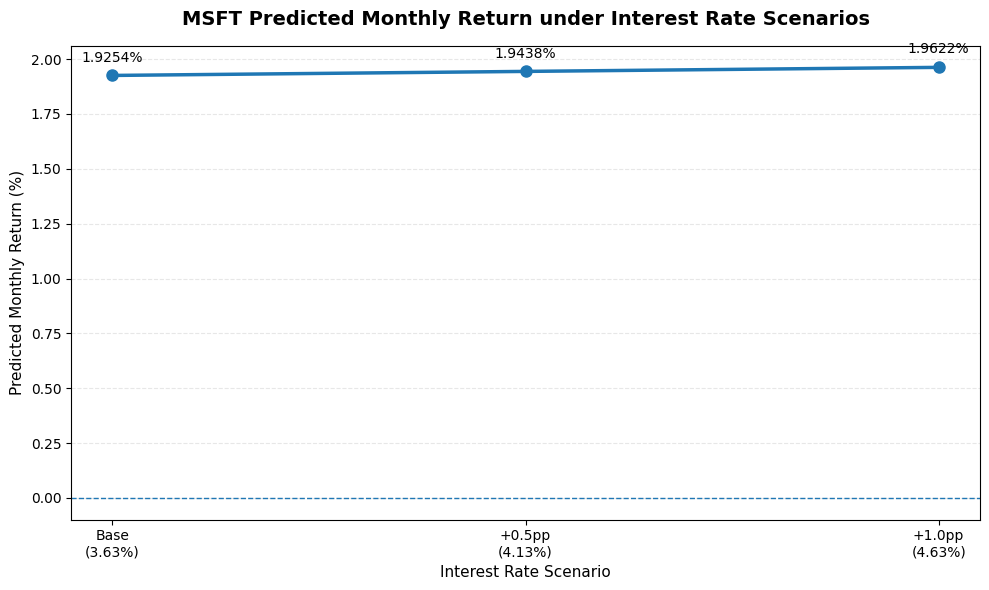

In [43]:
plt.figure(figsize=(10, 6))

x = range(len(result))
y = result['Predicted_Return']

plt.plot(
    x,
    y,
    marker='o',
    linewidth=2.5,
    markersize=8
)

# Hiển thị giá trị trên từng điểm
for i, value in enumerate(y):
    plt.annotate(
        f'{value:.4f}%',
        (i, value),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10
    )

# Đường tham chiếu 0%
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xticks(
    x,
    [
        'Base\n(3.63%)',
        '+0.5pp\n(4.13%)',
        '+1.0pp\n(4.63%)'
    ]
)

plt.xlabel('Interest Rate Scenario', fontsize=11)
plt.ylabel('Predicted Monthly Return (%)', fontsize=11)

plt.title(
    'MSFT Predicted Monthly Return under Interest Rate Scenarios',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 5.7.2. Biểu đồ lợi suất dự báo với khoảng dự báo 95% (Prediction Interval)

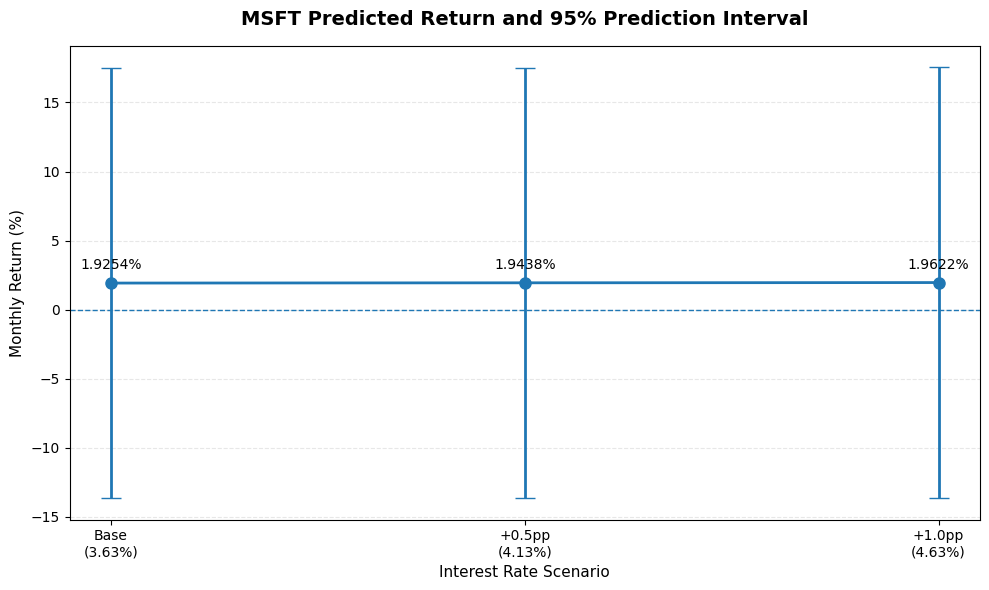

In [44]:
plt.figure(figsize=(10, 6))

x = np.arange(len(result))

y = result['Predicted_Return']

lower = result['PI_Lower']
upper = result['PI_Upper']

plt.errorbar(
    x,
    y,
    yerr=[
        y - lower,
        upper - y
    ],
    fmt='o-',
    capsize=7,
    linewidth=2,
    markersize=8
)

for i, value in enumerate(y):
    plt.annotate(
        f'{value:.4f}%',
        (i, value),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10
    )

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xticks(
    x,
    [
        'Base\n(3.63%)',
        '+0.5pp\n(4.13%)',
        '+1.0pp\n(4.63%)'
    ]
)

plt.xlabel('Interest Rate Scenario', fontsize=11)
plt.ylabel('Monthly Return (%)', fontsize=11)

plt.title(
    'MSFT Predicted Return and 95% Prediction Interval',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 5.8. Nhận xét kết quả Scenario Analysis

Phân tích kịch bản kiểm tra xem lợi suất tháng dự báo của MSFT thay đổi như thế nào khi lãi suất thay đổi, trong khi tỷ lệ lạm phát được giữ cố định ở mức thực tế gần nhất (~3.35%).

**Kết quả chính:**
- Ở kịch bản **Base** (lãi suất 3.63%), mô hình dự báo lợi suất tháng là **1.9254%**.
- Khi lãi suất tăng thêm **+0.5pp** (4.13%), lợi suất dự báo tăng nhẹ lên **1.9438%**.
- Khi lãi suất tăng thêm **+1.0pp** (4.63%), lợi suất dự báo tăng lên **1.9622%**.

**Lưu ý quan trọng:**
Mặc dù mô hình cho thấy lợi suất dự báo tăng nhẹ khi lãi suất tăng, kết quả này **không được** hiểu là bằng chứng rằng lãi suất cao hơn sẽ làm tăng lợi suất MSFT. Hệ số hồi quy của biến Interest Rate trong mô hình **không có ý nghĩa thống kê**. Do đó, kết quả scenario analysis nên được hiểu là phản ứng có điều kiện của mô hình hồi quy, chứ không phải là dự báo đáng tin cậy về lợi suất trong tương lai.

Khoảng dự báo 95% (PI) cũng tương đối rộng ở tất cả các kịch bản, cho thấy **độ không chắc chắn cao** khi dự báo lợi suất của một cổ phiếu riêng lẻ.

**Kết luận:** Kết quả scenario analysis chủ yếu minh họa độ nhạy của mô hình với giả định lãi suất, không nên sử dụng như dự báo chính xác về hiệu suất trong tương lai của MSFT.